In [1]:
import time
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pickle
import copy
import os
import gc
import re

In [2]:
import pandas as pd

file_path = './question/train_data.csv'
data = pd.read_csv(file_path)

data.head()

,Unnamed: 0,Date,Booking_Made,Marketing_Budget,Website_Visits,Ticket_Price,Tickets_Sold,Sales_Revenue,Operating_Expenses,Profit
0,0,2021-01-01,False,1217.741919,11789,1000.0,2389,2389000.0,1.695727e+06,693273.009394
1,1,2021-01-02,False,1462.814357,11778,1000.0,2381,2381000.0,1.691967e+06,689032.764060
2,2,2021-01-03,False,1498.712891,11804,1000.0,2369,2369000.0,1.686001e+06,682999.025547
3,3,2021-01-04,False,1243.245804,11809,1000.0,2371,2371000.0,1.686766e+06,684234.448174
4,4,2021-01-05,False,1307.334457,11444,1000.0,2334,2334000.0,1.668317e+06,665683.266002


# part 1

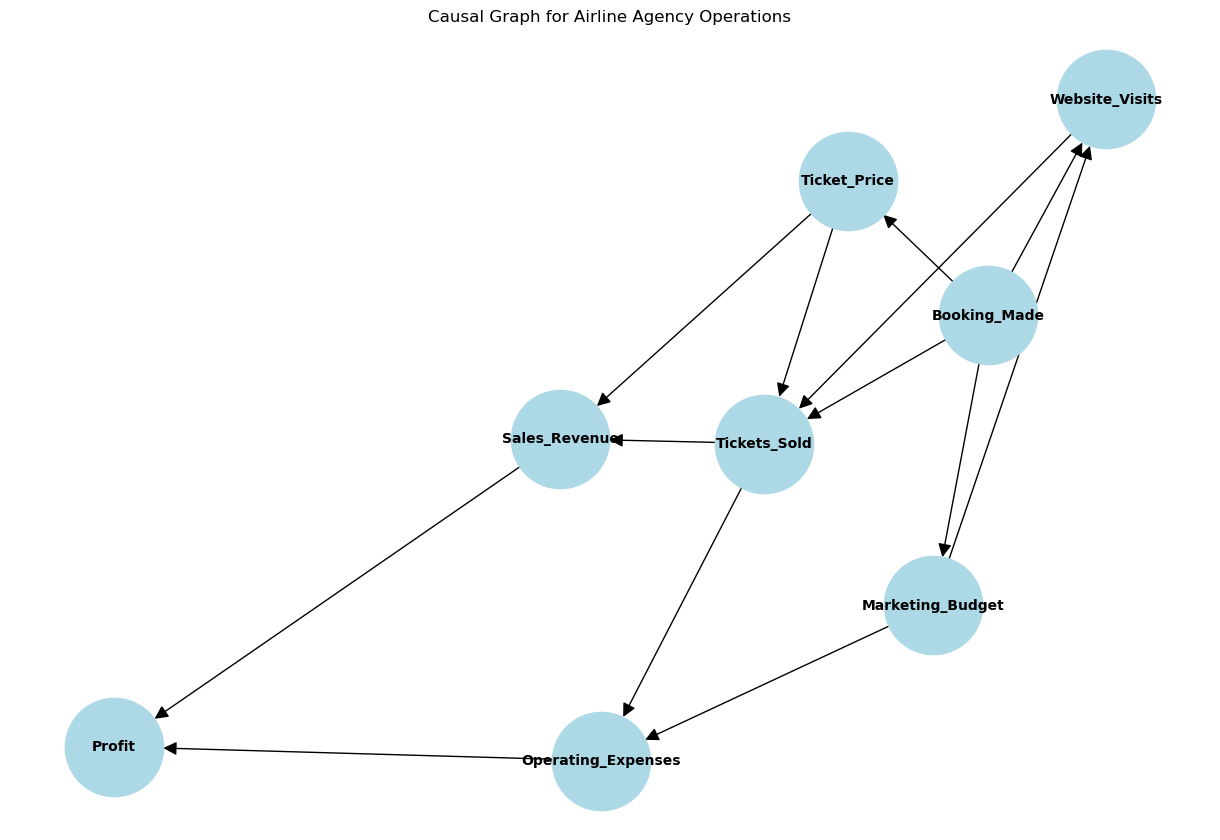

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

nodes = [
    'Booking_Made',
    'Marketing_Budget',
    'Website_Visits',
    'Ticket_Price',
    'Tickets_Sold',
    'Sales_Revenue',
    'Operating_Expenses',
    'Profit'
]

G.add_nodes_from(nodes)

edges = [
    ('Booking_Made', 'Marketing_Budget'),
    ('Booking_Made', 'Website_Visits'),
    ('Booking_Made', 'Tickets_Sold'),
    ('Booking_Made', 'Ticket_Price'),
    ('Marketing_Budget', 'Website_Visits'),
    ('Marketing_Budget', 'Operating_Expenses'),
    ('Website_Visits', 'Tickets_Sold'),
    ('Ticket_Price', 'Tickets_Sold'),
    ('Ticket_Price', 'Sales_Revenue'),
    ('Tickets_Sold', 'Sales_Revenue'),
    ('Tickets_Sold', 'Operating_Expenses'),
    ('Sales_Revenue', 'Profit'),
    ('Operating_Expenses', 'Profit')
]

G.add_edges_from(edges)

# Draw the causal graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=5000, font_size=10, font_weight='bold', arrowsize=20)
plt.title('Causal Graph for Airline Agency Operations')
plt.show()

# part 2

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression

X_booking_made = data[['Booking_Made']].astype(int)
X_marketing_budget = data[['Marketing_Budget']]
X_website_visits = data[['Website_Visits']]
X_ticket_price = data[['Ticket_Price']]
X_tickets_sold = data[['Tickets_Sold']]
X_sales_revenue = data[['Sales_Revenue']]
X_operating_expenses = data[['Operating_Expenses']]

# 1. Marketing_Budget = f(Booking_Made)
model_marketing_budget = LinearRegression().fit(X_booking_made, X_marketing_budget)

# 2. Website_Visits = f(Booking_Made, Marketing_Budget)
X_website_visits_combined = data[['Booking_Made', 'Marketing_Budget']].astype(int)
model_website_visits = LinearRegression()
model_website_visits.fit(X_website_visits_combined, X_website_visits)

# 3. Tickets_Sold = f(Booking_Made, Website_Visits, Ticket_Price)
X_tickets_sold_combined = data[['Booking_Made', 'Website_Visits', 'Ticket_Price']].astype(int)
model_tickets_sold = LinearRegression()
model_tickets_sold.fit(X_tickets_sold_combined, X_tickets_sold)

# 4. Ticket_Price = f(Booking_Made)
model_ticket_price = LinearRegression()
model_ticket_price.fit(X_booking_made, X_ticket_price)

# 5. Sales_Revenue = f(Ticket_Price, Tickets_Sold)
X_sales_revenue_combined = data[['Ticket_Price', 'Tickets_Sold']]
model_sales_revenue = LinearRegression()
model_sales_revenue.fit(X_sales_revenue_combined, X_sales_revenue)

# 6. Operating_Expenses = f(Marketing_Budget, Tickets_Sold)
X_operating_expenses_combined = data[['Marketing_Budget', 'Tickets_Sold']]
model_operating_expenses = LinearRegression()
model_operating_expenses.fit(X_operating_expenses_combined, X_operating_expenses)

# 7. Profit = f(Sales_Revenue, Operating_Expenses)
X_profit_combined = data[['Sales_Revenue', 'Operating_Expenses']]
y_profit = data[['Profit']]
model_profit = LinearRegression()
model_profit.fit(X_profit_combined, y_profit)

model_coefficients = {
    "Marketing_Budget": model_marketing_budget.coef_[0],
    "Website_Visits": model_website_visits.coef_[0],
    "Tickets_Sold": model_tickets_sold.coef_[0],
    "Ticket_Price": model_ticket_price.coef_[0],
    "Sales_Revenue": model_sales_revenue.coef_[0],
    "Operating_Expenses": model_operating_expenses.coef_[0],
    "Profit": model_profit.coef_[0]
}
# for key, val in model_coefficients.items():
#     print(f'{key}: {val}')

model_coefficients

{'Marketing_Budget': array([1368.00619298]),
 'Website_Visits': array([7.69966010e+03, 4.98221215e-01]),
 'Tickets_Sold': array([ 7.55081182e+02,  2.71063682e-01, -5.08802252e+00]),
 'Ticket_Price': array([-92.02432133]),
 'Sales_Revenue': array([6118.32176557, 1001.80577107]),
 'Operating_Expenses': array([  0.99724556, 500.00033724]),
 'Profit': array([ 1., -1.])}

# part 3

In [5]:
profit_variance = np.var(data['Profit'])

sales_revenue_variance = np.var(data['Sales_Revenue'])
operating_expenses_variance = np.var(data['Operating_Expenses'])

# Get the coefficients from the profit model
profit_coefficients = model_profit.coef_[0]

# Contribution of each variable to the profit variance
contribution_sales_revenue = profit_coefficients[0]**2 * sales_revenue_variance
contribution_operating_expenses = profit_coefficients[1]**2 * operating_expenses_variance

# Total contribution
total_contribution = contribution_sales_revenue + contribution_operating_expenses

# Contribution percentages
contribution_sales_revenue_pct = (contribution_sales_revenue / total_contribution) * 100
contribution_operating_expenses_pct = (contribution_operating_expenses / total_contribution) * 100

# Display results
contribution_results = {
    'Profit Variance': profit_variance,
    'Sales Revenue Variance': sales_revenue_variance,
    'Operating Expenses Variance': operating_expenses_variance,
    'Contribution of Sales Revenue to Profit Variance': contribution_sales_revenue,
    'Contribution of Operating Expenses to Profit Variance': contribution_operating_expenses,
    'Contribution of Sales Revenue to Profit Variance (%)': contribution_sales_revenue_pct,
    'Contribution of Operating Expenses to Profit Variance (%)': contribution_operating_expenses_pct
}

contribution_results

{'Profit Variance': 62106906567.094894,
 'Sales Revenue Variance': 359258964531.9619,
 'Operating Expenses Variance': 125923729356.7028,
 'Contribution of Sales Revenue to Profit Variance': 359258964531.9622,
 'Contribution of Operating Expenses to Profit Variance': 125923729356.70287,
 'Contribution of Sales Revenue to Profit Variance (%)': 74.0461209884789,
 'Contribution of Operating Expenses to Profit Variance (%)': 25.953879011521092}

# part 4

In [20]:
# Impact on sales_revenue and operating_expenses
# Variances of the key factors
ticket_price_variance = np.var(data['Ticket_Price'])
tickets_sold_variance = np.var(data['Tickets_Sold'])
marketing_budget_variance = np.var(data['Marketing_Budget'])

# Coefficients from the respective models
beta_sales_revenue_ticket_price = model_sales_revenue.coef_[0][0]
beta_sales_revenue_tickets_sold = model_sales_revenue.coef_[0][1]

beta_operating_expenses_marketing_budget = model_operating_expenses.coef_[0][0]
beta_operating_expenses_tickets_sold = model_operating_expenses.coef_[0][1]

# Contribution to Sales_Revenue variance
contribution_ticket_price_to_sales_revenue_variance = (beta_sales_revenue_ticket_price**2) * ticket_price_variance
contribution_tickets_sold_to_sales_revenue_variance = (beta_sales_revenue_tickets_sold**2) * tickets_sold_variance

# Contribution to Operating_Expenses variance
contribution_marketing_budget_to_operating_expenses_variance = (beta_operating_expenses_marketing_budget**2) * marketing_budget_variance
contribution_tickets_sold_to_operating_expenses_variance = (beta_operating_expenses_tickets_sold**2) * tickets_sold_variance

# Total contributions
total_sales_revenue_variance_contribution = contribution_ticket_price_to_sales_revenue_variance + contribution_tickets_sold_to_sales_revenue_variance
total_operating_expenses_variance_contribution = contribution_marketing_budget_to_operating_expenses_variance + contribution_tickets_sold_to_operating_expenses_variance

# Percent of Contribution
contribution_ticket_price_to_sales_revenue_variance_pct = (contribution_ticket_price_to_sales_revenue_variance / total_sales_revenue_variance_contribution) * 100
contribution_tickets_sold_to_sales_revenue_variance_pct = (contribution_tickets_sold_to_sales_revenue_variance / total_sales_revenue_variance_contribution) * 100
contribution_marketing_budget_to_operating_expenses_variance_pct = (contribution_marketing_budget_to_operating_expenses_variance / total_operating_expenses_variance_contribution) * 100
contribution_tickets_sold_to_operating_expenses_variance_pct = (contribution_tickets_sold_to_operating_expenses_variance / total_operating_expenses_variance_contribution) * 100

contribution_results = {
    'Contribution of Ticket Price to Sales Revenue Variance': contribution_ticket_price_to_sales_revenue_variance,
    'Contribution of Tickets Sold to Sales Revenue Variance': contribution_tickets_sold_to_sales_revenue_variance,
    'Contribution of Marketing Budget to Operating Expenses Variance': contribution_marketing_budget_to_operating_expenses_variance,
    'Contribution of Tickets Sold to Operating Expenses Variance': contribution_tickets_sold_to_operating_expenses_variance,
    'Contribution of Ticket Price to Sales Revenue Variance (%)': contribution_ticket_price_to_sales_revenue_variance_pct,
    'Contribution of Tickets Sold to Sales Revenue Variance (%)': contribution_tickets_sold_to_sales_revenue_variance_pct,
    'Contribution of Marketing Budget to Operating Expenses Variance (%)': contribution_marketing_budget_to_operating_expenses_variance_pct,
    'Contribution of Tickets Sold to Operating Expenses Variance (%)': contribution_tickets_sold_to_operating_expenses_variance_pct,
}

contribution_results

{'Contribution of Ticket Price to Sales Revenue Variance': 16838063685.28252,
 'Contribution of Tickets Sold to Sales Revenue Variance': 504752770079.56647,
 'Contribution of Marketing Budget to Operating Expenses Variance': 87893.85215627216,
 'Contribution of Tickets Sold to Operating Expenses Variance': 125733859614.74991,
 'Contribution of Ticket Price to Sales Revenue Variance (%)': 3.2282131117499078,
 'Contribution of Tickets Sold to Sales Revenue Variance (%)': 96.77178688825009,
 'Contribution of Marketing Budget to Operating Expenses Variance (%)': 6.990463108641277e-05,
 'Contribution of Tickets Sold to Operating Expenses Variance (%)': 99.99993009536891}

In [21]:
# Impact on Tickets_Sold
# Variances of the key factors
ticket_price_variance = np.var(data['Ticket_Price'])
booking_made_variance = np.var(data['Booking_Made'])
website_visits_variance = np.var(data['Website_Visits'])

# Coefficients from the respective model
beta_tickets_sold_ticket_price = model_tickets_sold.coef_[0][2]
beta_tickets_sold_booking_made = model_tickets_sold.coef_[0][0]
beta_tickets_sold_website_visits = model_tickets_sold.coef_[0][1]

# Contribution to Tickets_Sold variance
contribution_ticket_price_to_tickets_sold_variance = (beta_tickets_sold_ticket_price**2) * ticket_price_variance
contribution_booking_made_to_tickets_sold_variance = (beta_tickets_sold_booking_made**2) * booking_made_variance
contribution_website_visits_to_tickets_sold_variance = (beta_tickets_sold_website_visits**2) * website_visits_variance

# Total contributions
total_tickets_sold_variance_contribution = contribution_ticket_price_to_tickets_sold_variance + contribution_booking_made_to_tickets_sold_variance + contribution_website_visits_to_tickets_sold_variance

# Percent of Contribution
contribution_ticket_price_to_tickets_sold_variance_pct = (contribution_ticket_price_to_tickets_sold_variance / total_tickets_sold_variance_contribution) * 100
contribution_booking_made_to_tickets_sold_variance_pct = (contribution_booking_made_to_tickets_sold_variance / total_tickets_sold_variance_contribution) * 100
contribution_website_visits_to_tickets_sold_variance_pct = (contribution_website_visits_to_tickets_sold_variance / total_tickets_sold_variance_contribution) * 100

contribution_results = {
    'Contribution of ticket_price_to_tickets_sold Variance': contribution_ticket_price_to_tickets_sold_variance,
    'Contribution of booking_made_to_tickets_sold Variance': contribution_booking_made_to_tickets_sold_variance,
    'Contribution of website_visits_to_tickets_sold Variance': contribution_website_visits_to_tickets_sold_variance,
    'Contribution of ticket_price_to_tickets_sold Variance (%)': contribution_ticket_price_to_tickets_sold_variance_pct,
    'Contribution of booking_made_to_tickets_sold Variance (%)': contribution_booking_made_to_tickets_sold_variance_pct,
    'Contribution of website_visits_to_tickets_sold Variance (%)': contribution_website_visits_to_tickets_sold_variance_pct,
}
contribution_results

{'Contribution of ticket_price_to_tickets_sold Variance': 11644.626733822904,
 'Contribution of booking_made_to_tickets_sold Variance': 22467.81650299773,
 'Contribution of website_visits_to_tickets_sold Variance': 211209.83886605233,
 'Contribution of ticket_price_to_tickets_sold Variance (%)': 4.746664931536822,
 'Contribution of booking_made_to_tickets_sold Variance (%)': 9.158489930228237,
 'Contribution of website_visits_to_tickets_sold Variance (%)': 86.09484513823494}

In [22]:
# Impact on Website_Visits
# Variances of the key factors
booking_made_variance = np.var(data['Booking_Made'])
marketing_budget_variance = np.var(data['Marketing_Budget'])

# Coefficients from the respective model
beta_website_visits_booking_made = model_website_visits.coef_[0][0]
beta_website_visits_marketing_budget = model_website_visits.coef_[0][1]

# Contribution to Website_Visits variance
contribution_booking_made_to_website_visits_variance = (beta_website_visits_booking_made**2) * booking_made_variance
contribution_marketing_budget_to_website_visits_variance = (beta_website_visits_marketing_budget**2) * marketing_budget_variance

# Total contributions
total_website_visits_variance_contribution = contribution_booking_made_to_website_visits_variance + contribution_marketing_budget_to_website_visits_variance

# Percent of Contribution
contribution_booking_made_to_website_visits_variance_pct = (contribution_booking_made_to_website_visits_variance / total_website_visits_variance_contribution) * 100
contribution_marketing_budget_to_website_visits_variance_pct = (contribution_marketing_budget_to_website_visits_variance / total_website_visits_variance_contribution) * 100

contribution_results_website_visits = {
    'Contribution of Booking Made to Website Visits Variance': contribution_booking_made_to_website_visits_variance,
    'Contribution of Marketing Budget to Website Visits Variance': contribution_marketing_budget_to_website_visits_variance,
    'Contribution of Booking Made to Website Visits Variance (%)': contribution_booking_made_to_website_visits_variance_pct,
    'Contribution of Marketing Budget to Website Visits Variance (%)': contribution_marketing_budget_to_website_visits_variance_pct
}

contribution_results_website_visits

{'Contribution of Booking Made to Website Visits Variance': 2336235.838148713,
 'Contribution of Marketing Budget to Website Visits Variance': 21938.08473163837,
 'Contribution of Booking Made to Website Visits Variance (%)': 99.0697003084131,
 'Contribution of Marketing Budget to Website Visits Variance (%)': 0.9302996915868897}

In [23]:
# Impact on Ticket_Price
# Variances of the key factors
booking_made_variance = np.var(data['Booking_Made'])

# Coefficients from the respective model
beta_ticket_price_booking_made = model_ticket_price.coef_[0][0]

# Contribution to Ticket_Price variance
contribution_booking_made_to_ticket_price_variance = (beta_ticket_price_booking_made**2) * booking_made_variance

# Total contributions
total_ticket_price_variance_contribution = contribution_booking_made_to_ticket_price_variance

# Percent of Contribution
contribution_booking_made_to_ticket_price_variance_pct = (contribution_booking_made_to_ticket_price_variance / total_ticket_price_variance_contribution) * 100

contribution_results_ticket_price = {
    'Contribution of Booking Made to Ticket Price Variance': contribution_booking_made_to_ticket_price_variance,
    'Contribution of Booking Made to Ticket Price Variance (%)': contribution_booking_made_to_ticket_price_variance_pct
}

contribution_results_ticket_price

{'Contribution of Booking Made to Ticket Price Variance': 333.71737667949077,
 'Contribution of Booking Made to Ticket Price Variance (%)': 100.0}

In [24]:
# Impact on Marketing_Budget
# Variances of the key factors
booking_made_variance = np.var(data['Booking_Made'])

# Coefficients from the respective model
beta_marketing_budget_booking_made = model_marketing_budget.coef_[0][0]

# Contribution to Marketing_Budget variance
contribution_booking_made_to_marketing_budget_variance = (beta_marketing_budget_booking_made**2) * booking_made_variance

# Total contributions
total_marketing_budget_variance_contribution = contribution_booking_made_to_marketing_budget_variance

# Percent of Contribution
contribution_booking_made_to_marketing_budget_variance_pct = (contribution_booking_made_to_marketing_budget_variance / total_marketing_budget_variance_contribution) * 100

contribution_results_marketing_budget = {
    'Contribution of Booking Made to Marketing Budget Variance': contribution_booking_made_to_marketing_budget_variance,
    'Contribution of Booking Made to Marketing Budget Variance (%)': contribution_booking_made_to_marketing_budget_variance_pct
}

contribution_results_marketing_budget


{'Contribution of Booking Made to Marketing Budget Variance': 73747.9073455835,
 'Contribution of Booking Made to Marketing Budget Variance (%)': 100.0}

In [25]:
# No feature affect on Booking_made

In [54]:
# Impacts of features on the profit
contribution_sales_revenue_to_profit_pct = contribution_sales_revenue_pct/100

contribution_operating_expenses_to_profit_pct = contribution_operating_expenses_pct/100

contribution_tickets_sold_to_profit_pct = (
    contribution_sales_revenue_to_profit_pct * contribution_tickets_sold_to_sales_revenue_variance_pct/100 + 
    contribution_operating_expenses_to_profit_pct * contribution_tickets_sold_to_operating_expenses_variance_pct/100
)

contribution_ticket_price_to_profit_pct = (
    contribution_sales_revenue_to_profit_pct * contribution_ticket_price_to_sales_revenue_variance_pct/100 + 
    contribution_ticket_price_to_tickets_sold_variance_pct/100 * contribution_tickets_sold_to_profit_pct
)

contribution_website_visits_to_profit_pct = contribution_website_visits_to_tickets_sold_variance_pct/100 * contribution_tickets_sold_to_profit_pct

contribution_marketing_budget_to_profit_pct = (
    contribution_marketing_budget_to_operating_expenses_variance_pct/100 * contribution_operating_expenses_to_profit_pct +
    contribution_marketing_budget_to_website_visits_variance_pct/100 * contribution_website_visits_to_profit_pct
)

contribution_booking_made_to_profit_pct = (
    contribution_booking_made_to_tickets_sold_variance_pct/100 * contribution_tickets_sold_to_profit_pct +
    contribution_booking_made_to_marketing_budget_variance_pct/100 * contribution_marketing_budget_to_profit_pct +
    contribution_booking_made_to_ticket_price_variance_pct/100 * contribution_ticket_price_to_profit_pct +
    contribution_booking_made_to_website_visits_variance_pct/100 * contribution_website_visits_to_profit_pct
)

print('Impact of features on the profit:')
print('Impact of sales_revenue (%):', contribution_sales_revenue_to_profit_pct * 100)
print('Impact of operating_expenses (%):', contribution_operating_expenses_to_profit_pct * 100)
print('Impact of tickets_sold (%):', contribution_tickets_sold_to_profit_pct * 100)
print('Impact of ticket_price (%):', contribution_ticket_price_to_profit_pct * 100)
print('Impact of website_visits (%):', contribution_website_visits_to_profit_pct * 100)
print('Impact of marketing_budget (%):', contribution_marketing_budget_to_profit_pct * 100)
print('Impact of booking_made (%):', contribution_booking_made_to_profit_pct * 100)

Impact of features on the profit:
Impact of sales_revenue (%): 74.0461209884789
Impact of operating_expenses (%): 25.953879011521092
Impact of tickets_sold (%): 97.60961527054435
Impact of ticket_price (%): 7.023567964347216
Impact of website_visits (%): 84.03684710720208
Impact of marketing_budget (%): 0.7818126724210226
Impact of booking_made (%): 99.99999999999999
